In [3]:
from google.colab import drive
import zipfile
import os
# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

#voice_zip_path = "/content/drive/My Drive/project-2/Voice.zip"
audio_dir = "/content/drive/My Drive/project-2/Voice"
# Unzip the file
#with zipfile.ZipFile(voice_zip_path, 'r') as zip_ref:
    #zip_ref.extractall(audio_dir)

print("Extraction complete. Files are located in:", audio_dir)

Extraction complete. Files are located in: /content/drive/My Drive/project-2/Voice


In [5]:

#drawings_zip_path = "/content/drive/My Drive/project-2/drawings.zip"
drawings_dir = "/content/drive/My Drive/project-2/drawings"
# Unzip the file
#with zipfile.ZipFile(drawings_zip_path, 'r') as zip_ref:
    #zip_ref.extractall(drawings_dir)

print("Extraction complete. Files are located in:", drawings_dir)

Extraction complete. Files are located in: /content/drive/My Drive/project-2/drawings


In [6]:
# List files in the directory to check if they are accessible
print("Files in the audio directory:")
print(os.listdir(audio_dir))

# Initialize lists for features and labels
audio_features = []
labels = []  # Assuming you have labels for your data


Files in the audio directory:
['15 Young Healthy Control', "28 People with Parkinson's disease", '22 Elderly Healthy Control']


In [7]:
# Install necessary libraries
!pip install librosa
!pip install pandas
!pip install scikit-learn
!pip install tensorflow

In [8]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, log_loss, accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow_hub as hub
from tensorflow.keras.layers import Dense, Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [9]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer

# **PARKINSONS DRAWINGS**

In [10]:
dir_sp_train = '/content/drive/My Drive/project-2/drawings/spiral/training'
dir_sp_test = '/content/drive/My Drive/project-2/drawings/spiral/testing'
dir_wv_train = '/content/drive/My Drive/project-2/drawings/wave/training'
dir_wv_test = '/content/drive/My Drive/project-2/drawings/wave/testing'

In [11]:
Name=[]
for file in os.listdir(dir_sp_train):
    Name+=[file]
print(Name)
print(len(Name))

['healthy', 'parkinson']
2


In [12]:
N=[]
for i in range(len(Name)):
    N+=[i]

normal_mapping=dict(zip(Name,N))
reverse_mapping=dict(zip(N,Name))

def mapper(value):
    return reverse_mapping[value]

In [13]:
dataset_sp=[]
count=0
for file in os.listdir(dir_sp_train):
    path=os.path.join(dir_sp_train,file)
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im), color_mode='rgb', target_size=(100,100))
        image=img_to_array(image)
        image=image/255.0
        dataset_sp.append([image,count])
    count=count+1

testset_sp=[]
count=0
for file in os.listdir(dir_sp_test):
    path=os.path.join(dir_sp_test,file)
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im), color_mode='rgb', target_size=(100,100))
        image=img_to_array(image)
        image=image/255.0
        testset_sp.append([image,count])
    count=count+1

In [14]:
dataset_wv=[]
count=0
for file in os.listdir(dir_wv_train):
    path=os.path.join(dir_wv_train,file)
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im), color_mode='rgb', target_size=(100,100))
        image=img_to_array(image)
        image=image/255.0
        dataset_wv.append([image,count])
    count=count+1

testset_wv=[]
count=0
for file in os.listdir(dir_wv_test):
    path=os.path.join(dir_wv_test,file)
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im),  color_mode='rgb', target_size=(100,100))
        image=img_to_array(image)
        image=image/255.0
        testset_wv.append([image,count])
    count=count+1

In [15]:
data_sp,labels_sp0=zip(*dataset_sp)
test_sp,tlabels_sp0=zip(*testset_sp)

data_wv,labels_wv0=zip(*dataset_wv)
test_wv,tlabels_wv0=zip(*testset_wv)
labels_sp1=to_categorical(labels_sp0)
data_sp=np.array(data_sp)
labels_sp=np.array(labels_sp1)

tlabels_sp1=to_categorical(tlabels_sp0)
test_sp=np.array(test_sp)
tlabels_sp=np.array(tlabels_sp1)

labels_wv1=to_categorical(labels_wv0)
data_wv=np.array(data_wv)
labels_wv=np.array(labels_wv1)

tlabels_wv1=to_categorical(tlabels_wv0)
test_wv=np.array(test_wv)
tlabels_wv=np.array(tlabels_wv1)


In [16]:
trainx_sp,testx_sp,trainy_sp,testy_sp=train_test_split(data_sp,labels_sp,test_size=0.2,random_state=44)
trainx_wv,testx_wv,trainy_wv,testy_wv=train_test_split(data_wv,labels_wv,test_size=0.2,random_state=44)

In [17]:
datagen = ImageDataGenerator(horizontal_flip=True,vertical_flip=True,rotation_range=20,zoom_range=0.2,
                        width_shift_range=0.2,height_shift_range=0.2,shear_range=0.1,fill_mode="nearest")

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, concatenate
from tensorflow.keras.models import Model

# Hybrid Model: Combining InceptionV3 and DenseNet201

def create_hybrid_model(input_shape=(100, 100, 3)):
    # Load InceptionV3 as the feature extractor
    pretrained_inception = tf.keras.applications.InceptionV3(input_shape=input_shape, include_top=False, weights='imagenet')
    pretrained_inception.trainable = False  # Freeze the weights of InceptionV3

    # Load DenseNet201 as an additional feature extractor
    pretrained_densenet = tf.keras.applications.DenseNet201(input_shape=input_shape, include_top=False, weights='imagenet')
    pretrained_densenet.trainable = False  # Freeze the weights of DenseNet201

    # Input for the model
    inputs = tf.keras.Input(shape=input_shape)

    # InceptionV3 feature extractor
    x_inception = pretrained_inception(inputs)
    x_inception = GlobalAveragePooling2D()(x_inception)

    # DenseNet201 feature extractor
    x_densenet = pretrained_densenet(inputs)
    x_densenet = GlobalAveragePooling2D()(x_densenet)

    # Concatenate the features from both models
    x = concatenate([x_inception, x_densenet])

    # Add a fully connected layer with 128 units
    x = Dense(128, activation='relu')(x)

    # Output layer for classification
    outputs = Dense(2, activation='softmax')(x)

    # Final hybrid model
    model = Model(inputs=inputs, outputs=outputs)
    return model


In [19]:
# Create the hybrid model instead of DenseNet201
model3 = create_hybrid_model(input_shape=(100, 100, 3))
model4 = create_hybrid_model(input_shape=(100, 100, 3))

# Compile the models
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [20]:
# Train the hybrid models
his3 = model3.fit(datagen.flow(trainx_sp, trainy_sp, batch_size=32), validation_data=(testx_sp, testy_sp), epochs=50)
his4 = model4.fit(datagen.flow(trainx_wv, trainy_wv, batch_size=32), validation_data=(testx_wv, testy_wv), epochs=50)

# Spiral Model Evaluation
y_pred_sp = model3.predict(testx_sp)
pred_sp = np.argmax(y_pred_sp, axis=1)
ground_sp = np.argmax(testy_sp, axis=1)
print(classification_report(ground_sp, pred_sp))

# Wave Model Evaluation
y_pred_wv = model4.predict(testx_wv)
pred_wv = np.argmax(y_pred_wv, axis=1)
ground_wv = np.argmax(testy_wv, axis=1)
print(classification_report(ground_wv, pred_wv))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 138s 79s/step - accuracy: 0.4486 - loss: 2.3837 - val_accuracy: 0.6000 - val_loss: 1.2070
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5526 - loss: 1.2660 - val_accuracy: 0.4000 - val_loss: 1.4867
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.5501 - loss: 1.0653 - val_accuracy: 0.4667 - val_loss: 0.9784
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5852 - loss: 0.7761 - val_accuracy: 0.6000 - val_loss: 0.5547
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5226 - loss: 0.7306 - val_accuracy: 0.7333 - val_loss: 0.5008
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6879 - loss: 0.5832 - val_accuracy: 0.7333 - val_loss: 0.5048
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.8193 - loss: 0.4917 - val_accuracy: 0.6667 - val_loss: 0.6396
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.6632 - loss: 0.5559 - val_accuracy: 0.7333 - val_loss:

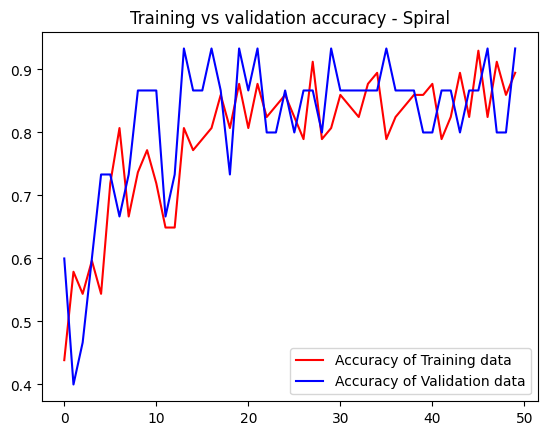

<Figure size 640x480 with 0 Axes>

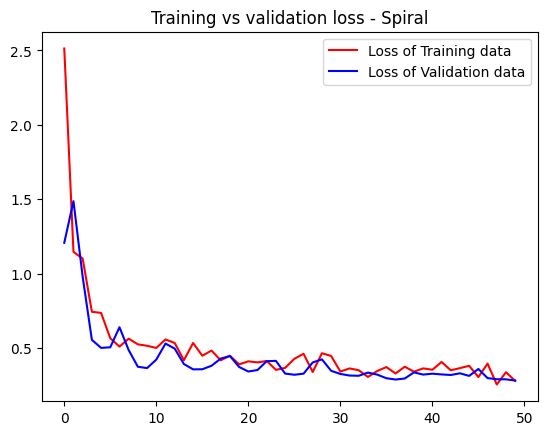

<Figure size 640x480 with 0 Axes>

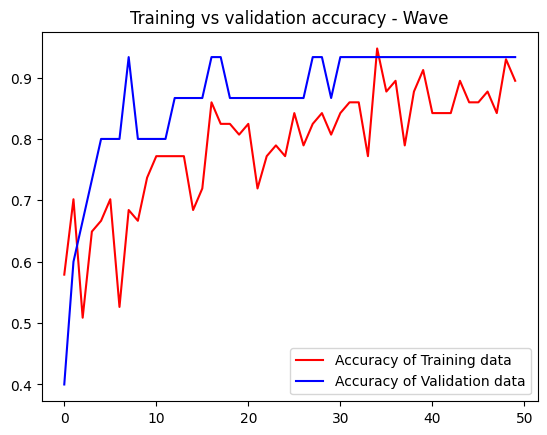

<Figure size 640x480 with 0 Axes>

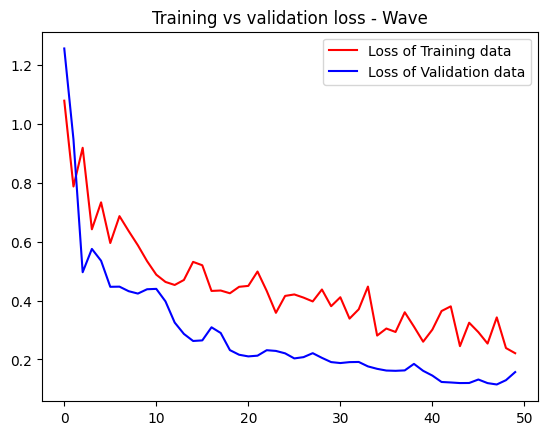

<Figure size 640x480 with 0 Axes>

In [21]:
get_acc3 = his3.history['accuracy']
value_acc3 = his3.history['val_accuracy']
get_loss3 = his3.history['loss']
validation_loss3 = his3.history['val_loss']

epochs3 = range(len(get_acc3))
plt.plot(epochs3, get_acc3, 'r', label='Accuracy of Training data')
plt.plot(epochs3, value_acc3, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy - Spiral')
plt.legend(loc=0)
plt.figure()
plt.show()

epochs3 = range(len(get_loss3))
plt.plot(epochs3, get_loss3, 'r', label='Loss of Training data')
plt.plot(epochs3, validation_loss3, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss - Spiral')
plt.legend(loc=0)
plt.figure()
plt.show()

get_acc4 = his4.history['accuracy']
value_acc4 = his4.history['val_accuracy']
get_loss4 = his4.history['loss']
validation_loss4 = his4.history['val_loss']

epochs4 = range(len(get_acc4))
plt.plot(epochs4, get_acc4, 'r', label='Accuracy of Training data')
plt.plot(epochs4, value_acc4, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy - Wave')
plt.legend(loc=0)
plt.figure()
plt.show()

epochs4 = range(len(get_loss4))
plt.plot(epochs4, get_loss4, 'r', label='Loss of Training data')
plt.plot(epochs4, validation_loss4, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss - Wave')
plt.legend(loc=0)
plt.figure()
plt.show()


In [22]:
print(test_sp.shape)
prediction_sp=model3.predict(test_sp)
print(prediction_sp.shape)

PRED_sp=[]
for item in prediction_sp:
    value_sp=np.argmax(item)
    PRED_sp+=[value_sp]

ANS_sp=tlabels_sp0
accuracy_sp=accuracy_score(ANS_sp,PRED_sp)
print(accuracy_sp)
print(test_wv.shape)
prediction_wv=model4.predict(test_wv)
print(prediction_wv.shape)

PRED_wv=[]
for item in prediction_wv:
    value_wv=np.argmax(item)
    PRED_wv+=[value_wv]

ANS_wv=tlabels_wv0
accuracy_wv=accuracy_score(ANS_wv,PRED_wv)
print(accuracy_wv)

(30, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 33s 33s/step
(30, 2)
0.7666666666666667
(30, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
(30, 2)
0.9


# **PARKINSONS VOICE DETECTION**

In [ ]:
# Function to extract features from audio files
def extract_features(file_path):
    # Load audio file
    audio, sample_rate = librosa.load(file_path, sr=None)

    # Extract features
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    return mfccs_scaled



In [24]:
# Initialize lists for features and labels
audio_features = []
labels = []  # Assuming you have labels for your data

# Install necessary library
!pip install soundfile

import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf  # Import soundfile for handling potential errors
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer

# Function to extract features from audio files
def extract_features(file_path):
    try:
        # Load audio file using soundfile first
        audio, sample_rate = sf.read(file_path)

        # If successful, proceed with feature extraction
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
        mfccs_scaled = np.mean(mfccs.T, axis=0)

        return mfccs_scaled

    except (sf.LibsndfileError, EOFError) as e:
        print(f"Error reading file {file_path}: {e}")
        # Handle the error, for example, skip the file or return an empty feature vector
        return np.zeros(13)  # Return an empty feature vector


# Loop through subdirectories and extract features (rest of the code remains the same)

# Loop through subdirectories and extract features
for root, dirs, files in os.walk(audio_dir):
    for filename in files:
        if filename.endswith('.wav'):
            file_path = os.path.join(root, filename)
            features = extract_features(file_path)
            audio_features.append(features)
            # Append corresponding label (you need to define how to get labels)
            # Example: Extract label from the directory name
            if "Parkinson" in root:
                labels.append(1)  # Label for Parkinson's disease
            else:
                labels.append(0)  # Label for healthy controls

# Convert to numpy arrays
X_audio = np.array(audio_features)
y_audio = np.array(labels)

# Debugging: Check the shape of the feature array
print(f"Extracted features shape: {X_audio.shape}")
print(f"Labels shape: {y_audio.shape}")

# Check if features were extracted
if X_audio.shape[0] == 0:
    raise ValueError("No audio features were extracted. Please check the audio files and path.")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_audio, y_audio, test_size=0.2, random_state=42)

Extracted features shape: (831, 13)
Labels shape: (831,)


In [25]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_audio, y_audio, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training set shape: (664, 13), Training labels shape: (664,)
Testing set shape: (167, 13), Testing labels shape: (167,)


In [26]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from tensorflow.keras import layers, Model

def build_vae(input_shape):
    # Encoder
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)

    # Latent space
    z_mean = layers.Dense(32)(x)
    z_log_var = layers.Dense(32)(x)

    # Sampling function
    def sampling(args):
        z_mean, z_log_var = args
        epsilon = tf.keras.backend.random_normal(shape=(tf.shape(z_mean)[0], 32))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    # Decoder
    decoder_input = layers.Input(shape=(32,))
    x = layers.Dense(64, activation='relu')(decoder_input)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(input_shape[0], activation='sigmoid')(x)

    encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
    decoder = Model(decoder_input, outputs, name='decoder')

    return encoder, decoder

In [28]:
from tensorflow.keras.layers import Layer # Import the Layer class

class LatentToTransformerInput(Layer):
    def call(self, inputs):
        # Reshape the latent vector to match the expected input shape for the transformer
        return tf.expand_dims(inputs, axis=1)  # Add a sequence length dimension

In [29]:
def build_transformer(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(2, activation='softmax')(x)  # Assuming binary classification

    model = Model(inputs, outputs, name='transformer')
    return model

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model

def build_hybrid_model(input_shape):
    encoder, decoder = build_vae(input_shape)
    transformer = build_transformer((1, 32))  # Reshape for transformer input (sequence_length=1, features=32)

    # Input for VAE
    vae_input = layers.Input(shape=input_shape)
    z_mean, z_log_var, z = encoder(vae_input)

    # Use the custom layer to prepare the latent space representation for the transformer
    transformer_input = LatentToTransformerInput()(z)

    # Add dropout for regularization before passing to transformer
    transformer_input = layers.Dropout(0.3)(transformer_input)  # Dropout at 30%

    # Pass the transformed input to the transformer
    transformer_output = transformer(transformer_input)

    # Apply L2 regularization to the final output layer
    transformer_output = layers.Dense(
        transformer_output.shape[-1],
        activation='softmax',
        kernel_regularizer=regularizers.l2(0.01)  # L2 Regularization
    )(transformer_output)

    # Build the model
    hybrid_model = Model(vae_input, transformer_output, name='hybrid_model')

    # Compile with Adam optimizer
    hybrid_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return hybrid_model


In [31]:
# Prepare data
# X_audio = np.expand_dims(X_audio, axis=-1)  # Remove or modify this line to avoid unnecessary dimensions
X_train, X_test, y_train, y_test = train_test_split(X_audio, y_audio, test_size=0.2, random_state=42)

# Reshape X_train and X_test to 2D before scaling
X_train = X_train.reshape(X_train.shape[0], -1)  # Reshape to (num_samples, num_features)
X_test = X_test.reshape(X_test.shape[0], -1)    # Reshape to (num_samples, num_features)


# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Reshape before scaling
X_test = scaler.transform(X_test)      # Reshape before scaling

# Build and train the hybrid model
hybrid_model = build_hybrid_model(X_train.shape[1:])
history = hybrid_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 723ms/step - accuracy: 0.4359 - loss: 0.7716 - val_accuracy: 0.6766 - val_loss: 0.6790
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7966 - loss: 0.6625 - val_accuracy: 0.8024 - val_loss: 0.5804
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8627 - loss: 0.5789 - val_accuracy: 0.8743 - val_loss: 0.5320
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - loss: 0.5441 - val_accuracy: 0.8802 - val_loss: 0.5187
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9113 - loss: 0.5111 - val_accuracy: 0.8802 - val_loss: 0.5040
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9160 - loss: 0.5018 - val_accuracy: 0.8743 - val_loss: 0.5066
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9196 - loss: 0.4894 - val_accuracy: 0.8982 - val_loss: 0.4774
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9263 - loss: 0.4756 - val_accuracy: 0.8982 - val_lo

1/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step


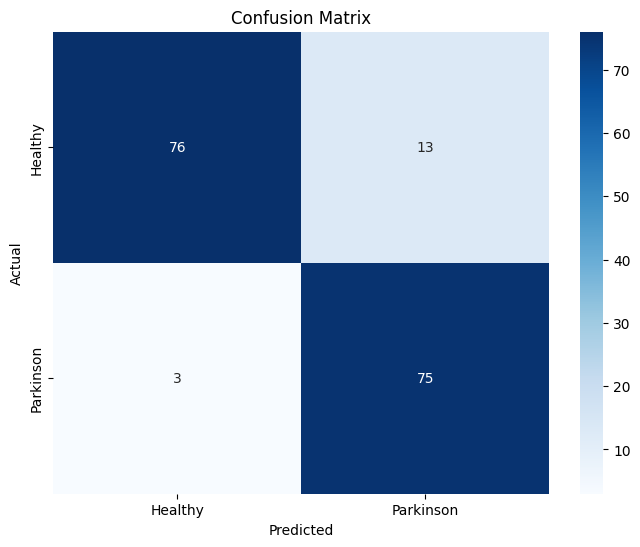

In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
# Predictions
y_pred = hybrid_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Parkinson'], yticklabels=['Healthy', 'Parkinson'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

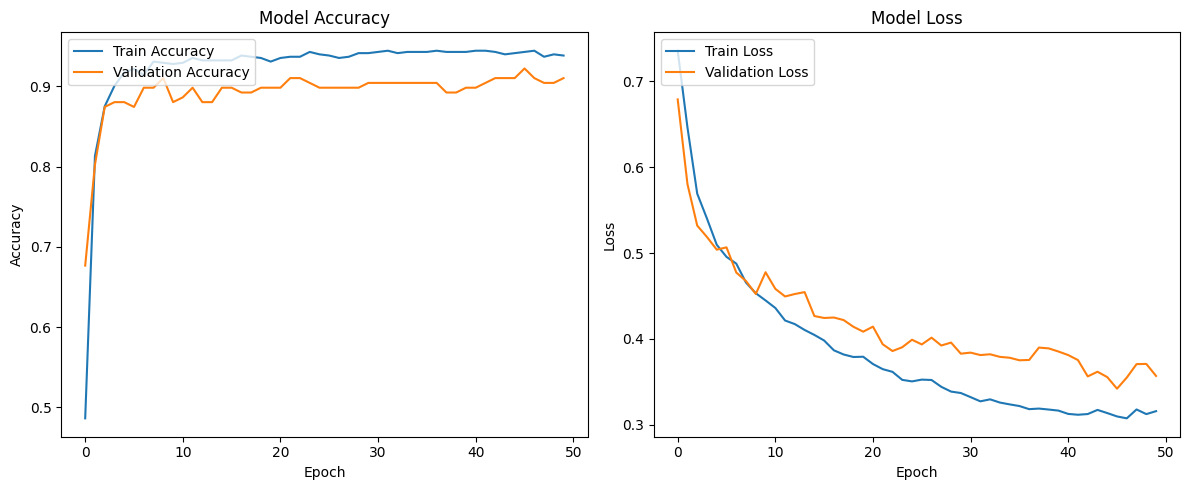

In [33]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# **MULTI_MODAL FUSION**

In [66]:
import tensorflow as tf
from tensorflow.keras.layers import Attention, Concatenate, Dense, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Modify fusion module to include dropout
def fusion_module(handwriting_features, voice_features):
    handwriting_features = tf.keras.layers.Reshape((1, 128))(handwriting_features)
    voice_features = tf.keras.layers.Reshape((1, 128))(voice_features)

    attention_layer = Attention()([handwriting_features, voice_features])

    handwriting_features = tf.keras.layers.Reshape((128,))(handwriting_features)
    voice_features = tf.keras.layers.Reshape((128,))(voice_features)
    attention_layer = tf.keras.layers.Reshape((128,))(attention_layer)

    fused_features = Concatenate()([handwriting_features, voice_features, attention_layer])

    # Fully connected layers with dropout and L2 regularization
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(fused_features)
    x = Dropout(0.3)(x)  # Dropout added
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.3)(x)  # Dropout added
    output = Dense(2, activation='softmax')(x)

    return output

# Apply early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



In [67]:
def create_feature_extractor(input_shape=(100, 100, 3)):
    """
    Creates a feature extractor combining InceptionV3 and DenseNet201.
    """
    pretrained_inception = tf.keras.applications.InceptionV3(input_shape=input_shape, include_top=False, weights='imagenet')
    pretrained_densenet = tf.keras.applications.DenseNet201(input_shape=input_shape, include_top=False, weights='imagenet')

    pretrained_inception.trainable = False
    pretrained_densenet.trainable = False

    inputs = Input(shape=input_shape)

    x_inception = GlobalAveragePooling2D()(pretrained_inception(inputs))
    x_densenet = GlobalAveragePooling2D()(pretrained_densenet(inputs))

    handwriting_features = Concatenate()([x_inception, x_densenet])
    handwriting_features = Dense(128, activation='relu')(handwriting_features)  # Project to shared embedding space

    return Model(inputs, handwriting_features, name="HandwritingFeatureExtractor")


In [68]:
def create_voice_feature_extractor(input_shape):
    """
    Creates a hybrid VAE-Transformer model for voice feature extraction.
    """
    encoder, _ = build_vae(input_shape)
    transformer = build_transformer((1, 32))  # Transformer expects (batch, sequence_length, features)

    vae_input = Input(shape=input_shape)
    z_mean, _, z = encoder(vae_input)

    transformer_input = LatentToTransformerInput()(z)
    transformer_features = transformer(transformer_input)

    voice_features = Dense(128, activation='relu')(transformer_features)  # Project to shared embedding space

    return Model(vae_input, voice_features, name="VoiceFeatureExtractor")


In [69]:
def build_multimodal_model(handwriting_shape=(100, 100, 3), voice_shape=(32,)):
    """
    Builds a multimodal model that fuses handwriting and voice features.
    """
    handwriting_extractor = create_feature_extractor(handwriting_shape)
    voice_extractor = create_voice_feature_extractor(voice_shape)

    handwriting_input = Input(shape=handwriting_shape, name="handwriting_input")
    voice_input = Input(shape=voice_shape, name="voice_input")

    handwriting_features = handwriting_extractor(handwriting_input)
    voice_features = voice_extractor(voice_input)

    fusion_output = fusion_module(handwriting_features, voice_features)

    multimodal_model = Model(inputs=[handwriting_input, voice_input], outputs=fusion_output, name="MultimodalParkinsonsModel")

    multimodal_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

    return multimodal_model


In [70]:
from tensorflow.keras.layers import Attention, Concatenate, Dense, Input
from tensorflow.keras.models import Model

train_handwriting = np.concatenate([trainx_sp, trainx_wv], axis=0)
train_voice = X_train

test_handwriting = np.concatenate([testx_sp, testx_wv], axis=0)
test_voice = X_test

train_labels = np.concatenate([trainy_sp, trainy_wv], axis=0)
test_labels = np.concatenate([testy_sp, testy_wv], axis=0)
multimodal_model = build_multimodal_model(handwriting_shape=(100, 100, 3), voice_shape=(32,))

In [71]:
print("train_handwriting shape:", train_handwriting.shape)
print("train_voice shape:", train_voice.shape)
print("train_labels shape:", train_labels.shape)


train_handwriting shape: (114, 100, 100, 3)
train_voice shape: (664, 13)
train_labels shape: (114, 2)


In [72]:
# Assuming each patient has a corresponding handwriting and voice sample
train_voice_fixed = train_voice[:114]  # Take the first 114 samples
test_voice_fixed = test_voice[:30]  # Take the first 30 samples


In [73]:
def pad_features(features, target_dim=32):
    if len(features) < target_dim:
        return np.pad(features, (0, target_dim - len(features)), mode='constant')
    return features[:target_dim]  # Trim if necessary

# Apply padding to all extracted features
train_voice_fixed = np.array([pad_features(f) for f in train_voice_fixed])
test_voice_fixed = np.array([pad_features(f) for f in test_voice_fixed])


In [74]:
print("Fixed train_voice shape:", train_voice_fixed.shape)  # Should be (114, 32)
print("Fixed test_voice shape:", test_voice_fixed.shape)  # Should be (30, 32)


Fixed train_voice shape: (114, 32)
Fixed test_voice shape: (30, 32)


In [75]:
history = multimodal_model.fit(
    [train_handwriting, train_voice_fixed],
    train_labels,
    validation_data=([test_handwriting, test_voice_fixed], test_labels),
    epochs=50,
    batch_size=32
)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 140s 26s/step - accuracy: 0.5074 - loss: 3.5359 - val_accuracy: 0.7667 - val_loss: 3.2213
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 158ms/step - accuracy: 0.5411 - loss: 3.4247 - val_accuracy: 0.6667 - val_loss: 3.0314
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.6316 - loss: 3.0917 - val_accuracy: 0.8333 - val_loss: 2.7336
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6842 - loss: 2.9012 - val_accuracy: 0.8667 - val_loss: 2.5976
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7928 - loss: 2.5553 - val_accuracy: 0.9000 - val_loss: 2.3731
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7877 - loss: 2.4272 - val_accuracy: 0.8667 - val_loss: 2.1833
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.8375 - loss: 2.2389 - val_accuracy: 0.8667 - val_loss: 1.9902
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8418 - loss: 2.0357 - val_accuracy: 0.8667 - val_loss: 1.8555
Epoch 

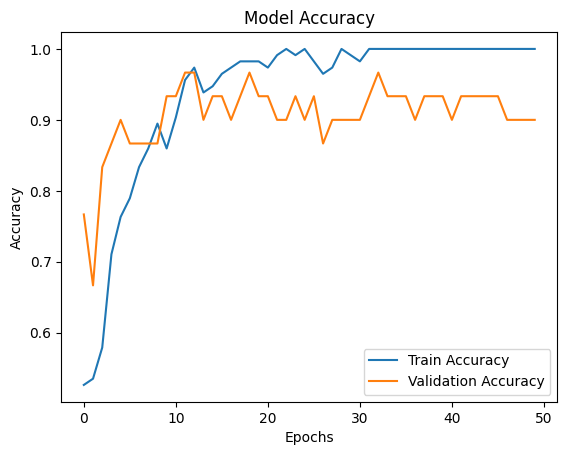

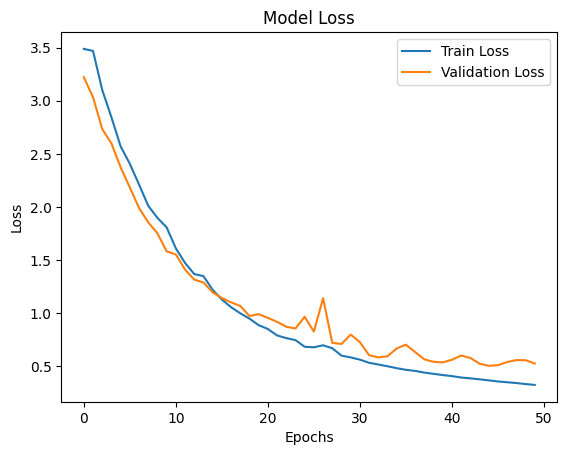

In [76]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (30, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step


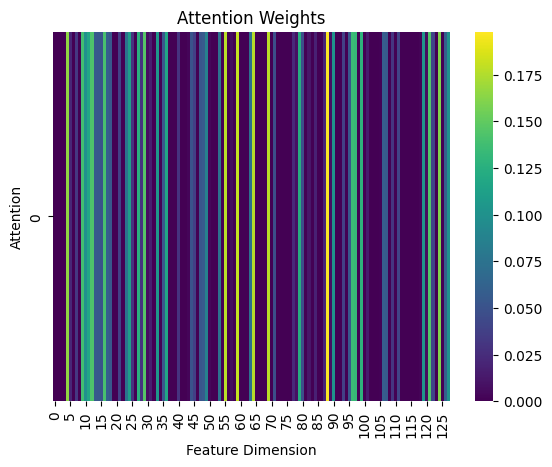

In [45]:
def create_attention_extractor(multimodal_model):
    """
    Create a model to extract attention weights from the multimodal model.
    """
    attention_layer_name = "attention"  # Corrected name based on your model's layer names
    attention_output_model = Model(
        inputs=multimodal_model.input,
        outputs=multimodal_model.get_layer(attention_layer_name).output
    )
    return attention_output_model

# Example usage:
attention_extractor = create_attention_extractor(multimodal_model)
attention_weights = attention_extractor.predict([test_handwriting, test_voice_fixed])

# Visualizing attention weights
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_weights(attention_weights, sample_idx=0):
    """
    Visualize attention weights for a specific sample.
    """
    sns.heatmap(attention_weights[sample_idx].reshape(1, -1), cmap="viridis", cbar=True)
    plt.title("Attention Weights")
    plt.xlabel("Feature Dimension")
    plt.ylabel("Attention")
    plt.show()

# Plot attention weights for a sample
plot_attention_weights(attention_weights)


In [46]:
!pip install lime


Shape of test_combined: (30, 30032)
Shape of aggregated SHAP values: (30, 30032)
Feature names length: 30032


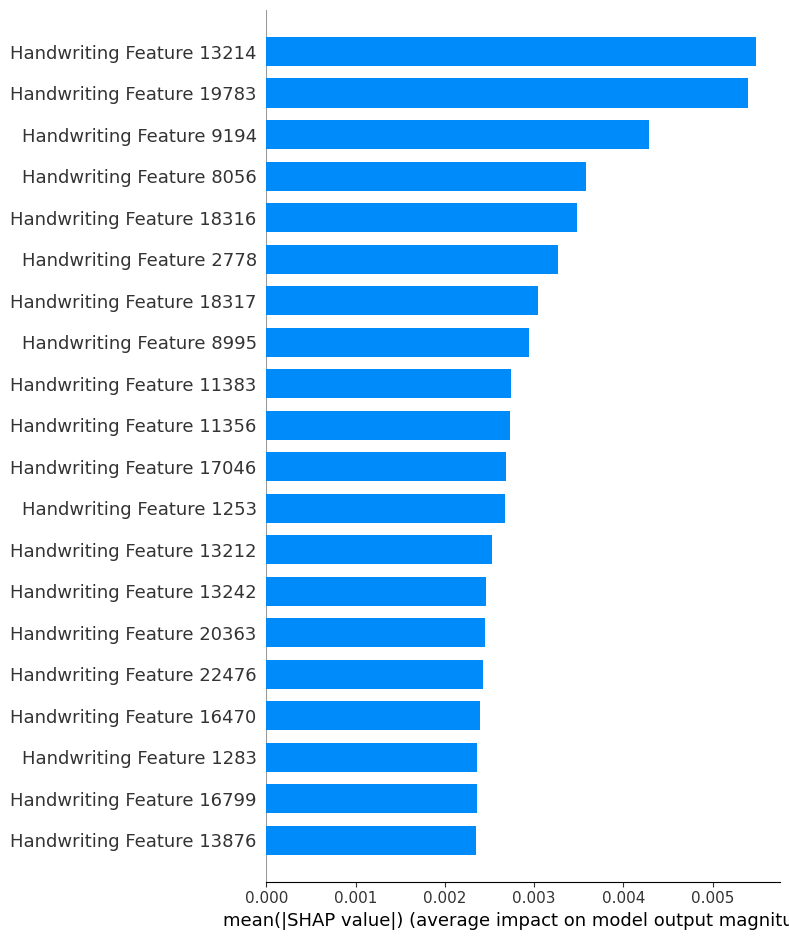

In [47]:
import shap
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Ensure the number of test samples match
min_test_samples = min(test_handwriting.shape[0], test_voice_fixed.shape[0])
test_handwriting = test_handwriting[:min_test_samples]
test_voice_fixed = test_voice_fixed[:min_test_samples]

# Flatten handwriting data and combine with voice features
test_combined = np.hstack((test_handwriting.reshape(test_handwriting.shape[0], -1), test_voice_fixed))

# Repeat for training data
min_train_samples = min(train_handwriting.shape[0], train_voice_fixed.shape[0])
train_handwriting = train_handwriting[:min_train_samples]
train_voice_fixed = train_voice_fixed[:min_train_samples]
train_combined = np.hstack((train_handwriting.reshape(train_handwriting.shape[0], -1), train_voice_fixed))

# Train a surrogate model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_combined, np.argmax(train_labels[:min_train_samples], axis=1))  # Assuming labels are one-hot encoded

# SHAP explainer
explainer = shap.Explainer(rf_model, train_combined)
shap_values = explainer(test_combined)

# Create feature names dynamically
num_handwriting_features = test_handwriting.reshape(test_handwriting.shape[0], -1).shape[1]
num_voice_features = test_voice_fixed.shape[1]
feature_names = [f"Handwriting Feature {i}" for i in range(num_handwriting_features)] + \
                [f"Voice Feature {i}" for i in range(num_voice_features)]

# Aggregate SHAP values across classes (e.g., mean absolute values across classes)
shap_values_mean = np.mean(np.abs(shap_values.values), axis=2)

# Debugging outputs
print("Shape of test_combined:", test_combined.shape)
print("Shape of aggregated SHAP values:", shap_values_mean.shape)
print("Feature names length:", len(feature_names))

# Visualize SHAP values
shap.summary_plot(
    shap_values_mean,  # Aggregated SHAP values
    test_combined,
    feature_names=feature_names,
    plot_type="bar"
)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1

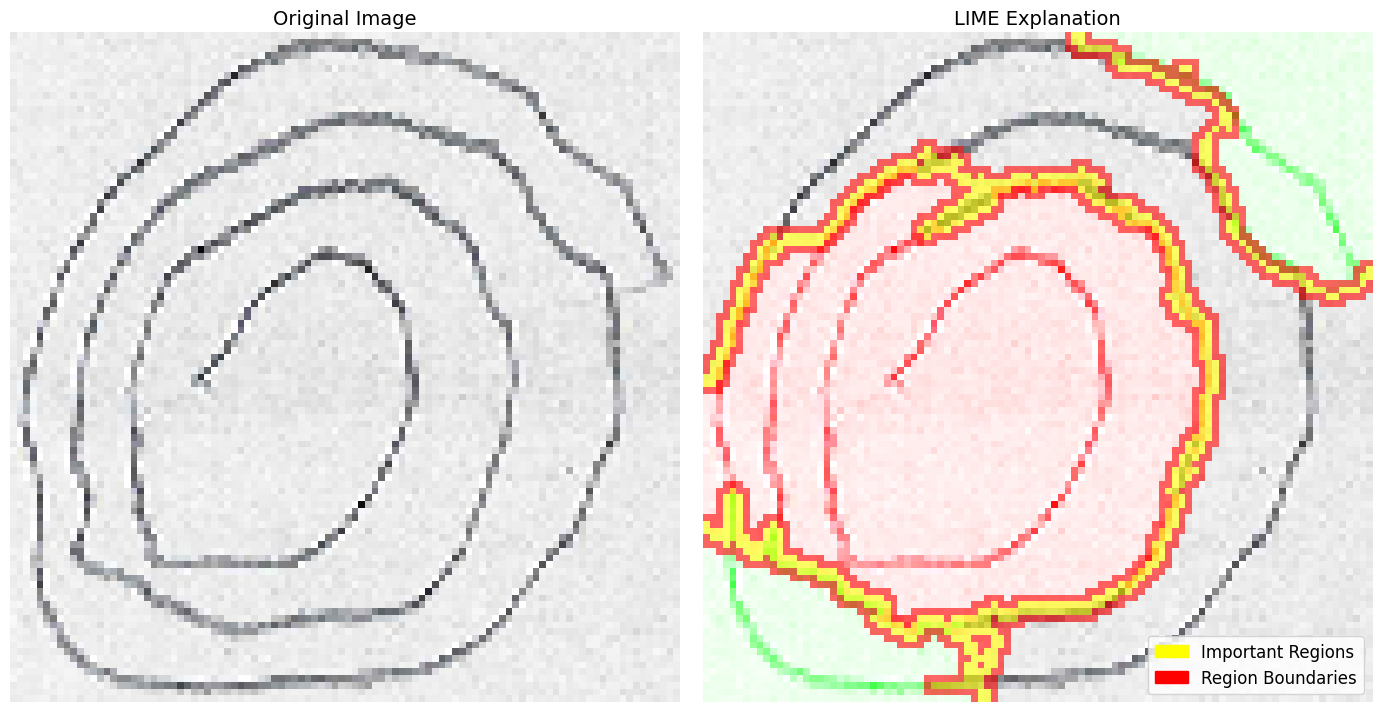

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━

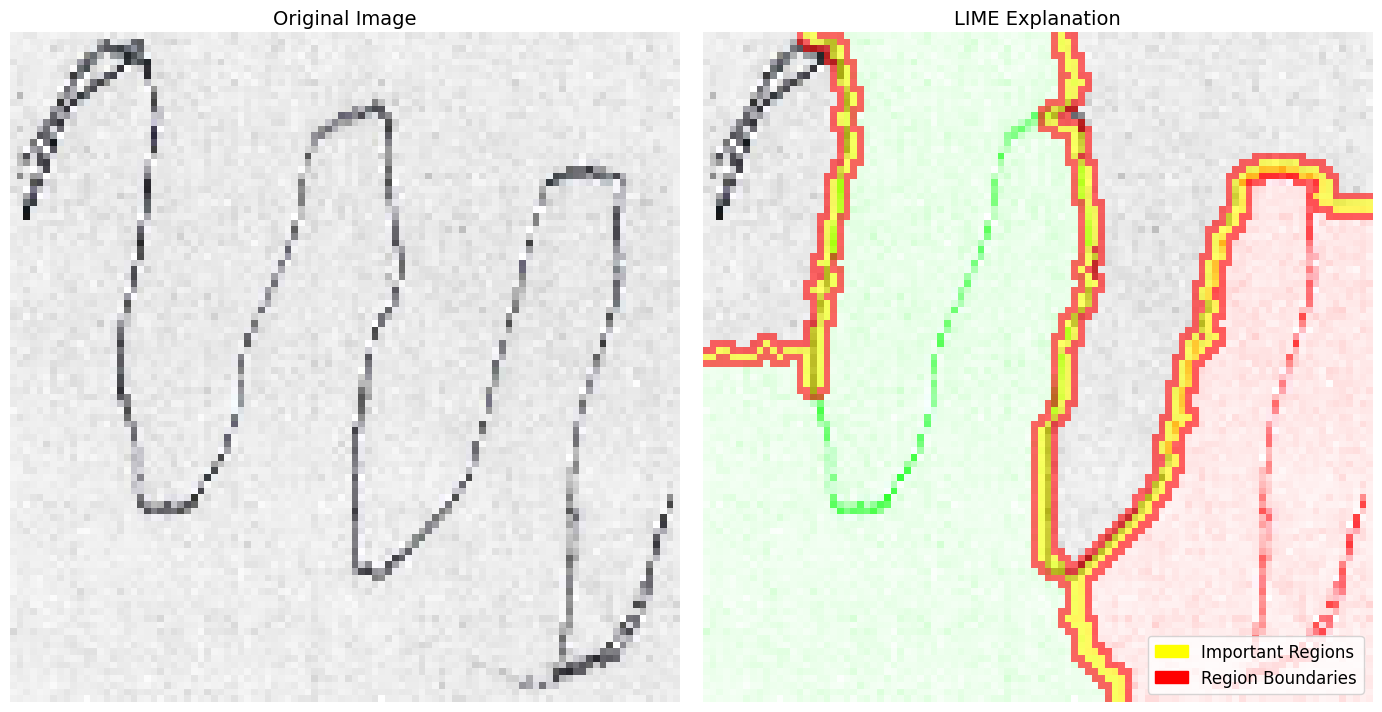

In [85]:
import lime
import lime.lime_image
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
import matplotlib.patches as mpatches

# ---- Improved LIME Explanation with Key ----
def lime_explain(model, images, index):
    explainer = lime.lime_image.LimeImageExplainer()

    # Explain the prediction
    explanation = explainer.explain_instance(
        images[index], model.predict, top_labels=2, hide_color=None, num_samples=1000
    )

    # Get explanation with mask
    temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=False,
        num_features=10,  # Increase number of features for more details
        hide_rest=False,  # Show full image with highlights
        min_weight=0.02   # Remove weak activations
    )

    # ---- Visualization ----
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    # Original Image
    ax[0].imshow(images[index], cmap="gray")
    ax[0].set_title("Original Image", fontsize=14)
    ax[0].axis("off")

    # LIME Explanation with improved mask overlay
    ax[1].imshow(temp, cmap="gray")
    ax[1].imshow(mark_boundaries(temp, mask, color=(1, 1, 0), outline_color=(1, 0, 0)), alpha=0.6)  # Yellow mask, red outline
    ax[1].set_title("LIME Explanation", fontsize=14)
    ax[1].axis("off")

    # ---- Add Key (Legend) ----
    yellow_patch = mpatches.Patch(color='yellow', label='Important Regions')
    red_patch = mpatches.Patch(color='red', label='Region Boundaries')

    ax[1].legend(handles=[yellow_patch, red_patch], loc='lower right', fontsize=12, frameon=True)

    plt.tight_layout()
    plt.show()

# Explain a sample image with improved visualization
lime_explain(model3, testx_sp, index=0)
lime_explain(model4, testx_wv, index=0)


  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:  60%|██████    | 3/5 [01:59<00:59, 29.97s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 100%|██████████| 5/5 [03:54<00:00, 47.49s/it]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 6it [04:52, 58.42s/it]


SHAP values type: <class 'shap._explanation.Explanation'>
SHAP values shape: (5, 100, 100, 3, 2)


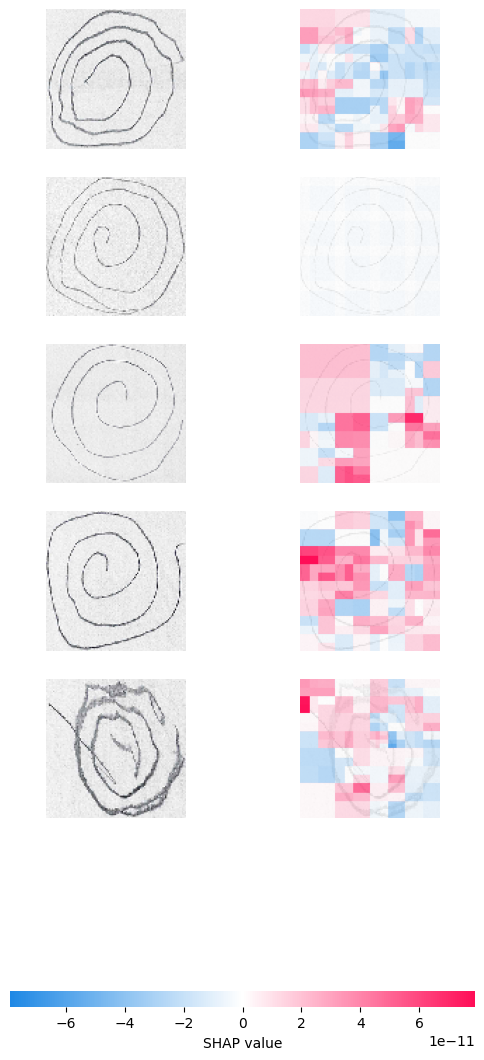

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:  60%|██████    | 3/5 [01:54<00:56, 28.28s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 100%|██████████| 5/5 [03:50<00:00, 47.39s/it]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 6it [04:47, 57.50s/it]


SHAP values type: <class 'shap._explanation.Explanation'>
SHAP values shape: (5, 100, 100, 3, 2)


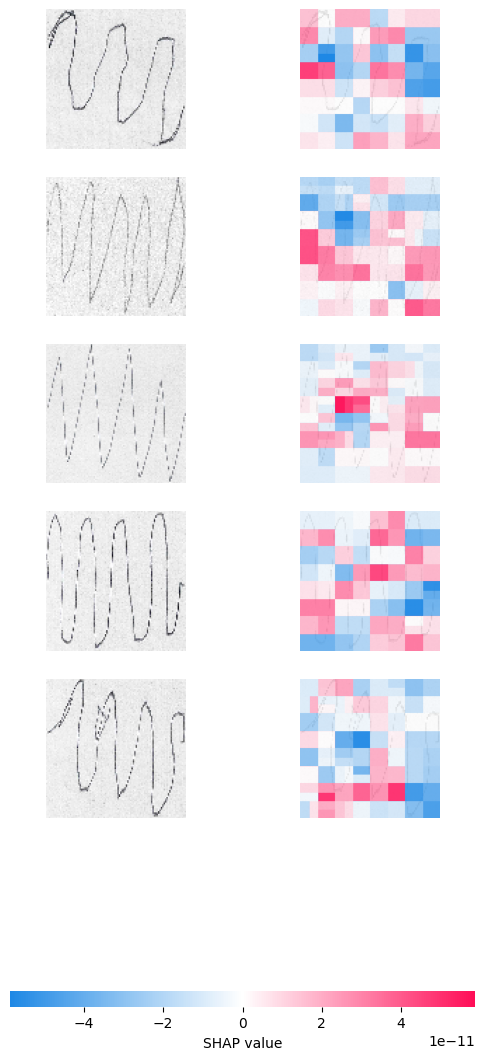

In [87]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Function to explain SHAP values
def shap_explain(model, test_images):
    test_images = np.array(test_images)

    # Ensure images have the correct shape
    if len(test_images.shape) == 3:
        test_images = test_images.reshape((-1, test_images.shape[1], test_images.shape[2], 1))

    masker = shap.maskers.Image("inpaint_telea", test_images[0].shape)

    explainer = shap.Explainer(model, masker)

    # Compute SHAP values
    shap_values = explainer(test_images[:5])

    # Debugging output
    print(f"SHAP values type: {type(shap_values)}")
    print(f"SHAP values shape: {shap_values.values.shape if hasattr(shap_values, 'values') else 'N/A'}")

    # Fix: Sum over the last axis if it exists
    shap_values_fixed = np.sum(shap_values.values, axis=-1) if shap_values.values.shape[-1] > 1 else shap_values.values

    # Plot the SHAP explanations
    shap.image_plot(shap_values_fixed, test_images[:5])

# Example usage
shap_explain(model3, testx_sp)
shap_explain(model4, testx_wv)


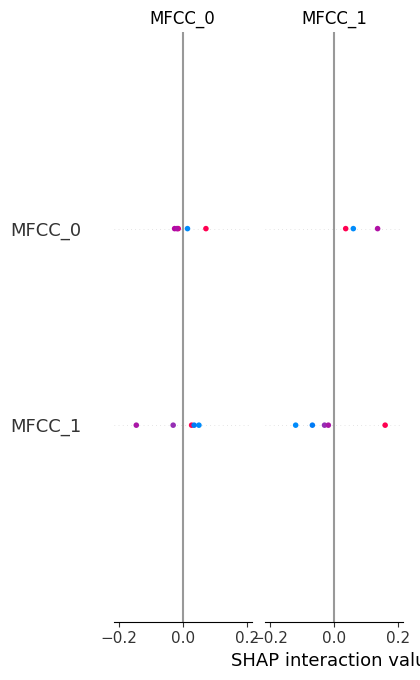

In [55]:
import shap
import numpy as np

# Create SHAP Explainer
explainer = shap.Explainer(hybrid_model, X_test)

# Compute SHAP values
shap_values = explainer(X_test[:5])  # Compute for first 5 test samples

# Extract SHAP values as a NumPy array
shap_values_array = shap_values.values  # Extract the actual values

# Ensure it's in the correct shape (samples, features)
shap_values_selected = np.squeeze(shap_values_array)  # (5, 13, 1) → (5, 13)

# Convert feature names to a NumPy array
feature_names = np.array(["MFCC_{}".format(i) for i in range(X_test.shape[1])])

# Plot SHAP summary
shap.summary_plot(shap_values_selected, X_test[:5], feature_names=feature_names)


In [81]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

# Create SHAP Explainer
explainer = shap.Explainer(hybrid_model, X_test)

# Compute SHAP values
shap_values = explainer(X_test[:5])

# Convert to DataFrame for Plotly
shap_df = pd.DataFrame(shap_values.values[:, :, 0], columns=["MFCC_{}".format(i) for i in range(X_test.shape[1])])

# Create an interactive scatter plot
fig = px.imshow(shap_df, labels=dict(color="SHAP Value"), height=800, width=1200)

# Enable zoom and scroll
fig.update_layout(dragmode="pan", xaxis=dict(side="top", tickangle=-45), yaxis=dict(autorange="reversed"))

# Show plot
fig.show()


In [78]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import files  # For file upload in Google Colab

# 🔹 Step 1: Upload Handwriting and Voice Samples
print("📤 Upload a handwriting image (JPG, PNG)...")
uploaded_image = files.upload()
image_path = list(uploaded_image.keys())[0]  # Get image filename

print("📤 Upload a voice sample (WAV format)...")
uploaded_audio = files.upload()
audio_path = list(uploaded_audio.keys())[0]  # Get audio filename

# 🔹 Step 2: Preprocess Handwriting Image
def preprocess_handwriting(image_path):
    image = load_img(image_path, target_size=(100, 100))
    image = img_to_array(image) / 255.0  # Normalize pixel values
    return np.expand_dims(image, axis=0)

# 🔹 Step 3: Preprocess Voice Sample
def preprocess_voice(audio_path, n_mfcc=32):
    audio, sample_rate = librosa.load(audio_path, sr=None)
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    features = np.mean(mfccs.T, axis=0)  # Compute mean across time

    # Ensure features are 32-dimensional (pad if needed)
    features = np.pad(features, (0, max(0, 32 - len(features))), mode='constant')
    return np.expand_dims(features, axis=0)

# Apply preprocessing functions
new_handwriting_sample = preprocess_handwriting(image_path)
new_voice_sample = preprocess_voice(audio_path)

# 🔹 Step 4: Make Prediction
new_prediction = multimodal_model.predict([new_handwriting_sample, new_voice_sample])
predicted_class = np.argmax(new_prediction)

# 🔹 Step 5: Display Prediction
print(" Predicted Class:", " Parkinson's" if predicted_class == 1 else " Healthy")


📤 Upload a handwriting image (JPG, PNG)...


Saving p_hand.png to p_hand.png
📤 Upload a voice sample (WAV format)...


Saving p_voice.wav to p_voice.wav


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
 Predicted Class:  Parkinson's
